# 01 — Análisis Descriptivo Univariante

**Objetivo:** Caracterizar la distribución de las cuatro variables dependientes normalizadas por minuto, evaluar su forma, identificar la familia de distribución más adecuada para cada una y orientar la elección del modelo (GLMM) en fases posteriores.

**Dataset:** `Matriz_V3.xlsx` (4 446 observaciones × 19 variables).

| VD | Descripción |
|---|---|
| `Total Touches / min` | Toques totales por minuto |
| `Golpeos +15 m/s / min` | Golpeos de alta velocidad por minuto |
| `Distance Covered (m) / min` | Distancia total recorrida por minuto |
| `High Intensity Distance (20 km/h) / min` | Distancia de alta intensidad por minuto |

---
## 1 · Carga y verificación

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuración general
np.random.seed(42)
warnings.filterwarnings("ignore")  # Evitar warnings de ajustes MLE
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})
%matplotlib inline

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ── Carga del dataset ─────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nTipos de datos:\n{df.dtypes.to_string()}")

Dimensiones: 4446 filas × 19 columnas

Tipos de datos:
Phase Id                                     int64
Agrupacion                                     str
Espacio                                        str
Polaridad                                      str
Equilibrio                                     str
NombreCorrecto                                 str
GrupoEdad                                      str
Phase Duration (min)                         int64
Player Id                                    int64
Position Category                              str
Position                                       str
Total Touches (#)                            int64
Total Touches / min                        float64
Golpeos +15 m/s                              int64
Golpeos +15 m/s / min                      float64
Distance Covered (m)                         int64
Distance Covered (m) / min                 float64
High Intensity Distance (20 km/h)            int64
High Intensity Distance (20

In [3]:
# ── Definición de las 4 VD normalizadas por minuto ────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]

# Etiquetas cortas para gráficos
vd_labels = [
    "Toques / min",
    "Golpeos +15 m/s / min",
    "Distancia (m) / min",
    "HID (m) / min",
]

# Verificación: todas las columnas existen y son numéricas
for col in vd_cols:
    assert col in df.columns, f"Columna '{col}' no encontrada."
    assert pd.api.types.is_numeric_dtype(df[col]), f"'{col}' no es numérica."

print("✔ Las 4 VD/min están presentes y son numéricas.")
df[vd_cols].head()

✔ Las 4 VD/min están presentes y son numéricas.


,Total Touches / min,Golpeos +15 m/s / min,Distance Covered (m) / min,High Intensity Distance (20 km/h) / min
0,2.538462,0.230769,84.692308,0.153846
1,1.615385,0.230769,70.461538,0.461538
2,2.615385,0.153846,84.153846,0.384615
3,0.230769,0.000000,60.076923,0.000000
4,1.384615,0.230769,113.769231,4.230769


---
## 2 · Estadísticos descriptivos globales

Para cada VD/min calculamos indicadores de tendencia central, dispersión, forma y proporción de ceros. Esto permite una primera caracterización rápida de cada distribución.

In [4]:
from scipy.stats import trim_mean, median_abs_deviation, skew, kurtosis

filas = []
for col, label in zip(vd_cols, vd_labels):
    x = df[col].dropna()
    n = len(x)
    media   = x.mean()
    mediana = x.median()
    media_r = trim_mean(x, proportiontocut=0.05)
    sd      = x.std()
    mad     = median_abs_deviation(x)
    iqr     = x.quantile(0.75) - x.quantile(0.25)
    cv      = sd / media if media != 0 else np.nan
    g1      = skew(x)
    g2      = kurtosis(x)           # exceso de curtosis (Fisher)
    pct0    = (x == 0).sum() / n * 100
    vm      = x.var() / media if media != 0 else np.nan   # ratio V/M

    filas.append({
        "Variable": label,
        "n": n,
        "Media": media,
        "Mediana": mediana,
        "Media rec. 5 %": media_r,
        "SD": sd,
        "MAD": mad,
        "IQR": iqr,
        "CV": cv,
        "Asimetría (g₁)": g1,
        "Curtosis (g₂)": g2,
        "% ceros": pct0,
        "V/M ratio": vm,
    })

df_desc = pd.DataFrame(filas).set_index("Variable")

# Formateo para presentación
df_desc.style.format({
    "n":              "{:.0f}",
    "Media":          "{:.3f}",
    "Mediana":        "{:.3f}",
    "Media rec. 5 %":"{:.3f}",
    "SD":             "{:.3f}",
    "MAD":            "{:.3f}",
    "IQR":            "{:.3f}",
    "CV":             "{:.3f}",
    "Asimetría (g₁)":"{:.3f}",
    "Curtosis (g₂)": "{:.3f}",
    "% ceros":        "{:.2f}",
    "V/M ratio":      "{:.3f}",
}).set_caption("Tabla 1 — Estadísticos descriptivos de las VD normalizadas por minuto")

,n,Media,Mediana,Media rec. 5 %,SD,MAD,IQR,CV,Asimetría (g₁),Curtosis (g₂),% ceros,V/M ratio
Variable,,,,,,,,,,,,
Toques / min,4446,2.489,2.042,2.314,1.776,0.917,1.956,0.714,1.773,4.725,0.00,1.267
Golpeos +15 m/s / min,4446,0.163,0.111,0.136,0.222,0.111,0.230,1.356,4.832,52.926,29.51,0.300
Distancia (m) / min,4446,79.168,78.385,79.004,28.213,21.030,42.182,0.356,0.097,-0.487,0.00,10.055
HID (m) / min,4446,1.857,0.562,1.405,3.202,0.562,2.400,1.724,4.722,44.851,30.09,5.521


**Lectura rápida de la tabla:**

- **Media vs. Mediana:** Si difieren considerablemente, la distribución es asimétrica.  
- **CV > 1:** Alta variabilidad relativa.  
- **g₁ > 0:** Sesgo positivo (cola derecha).  
- **g₂ > 0:** Distribución leptocúrtica (colas más pesadas que la normal).  
- **% ceros:** Un porcentaje elevado sugiere la necesidad de modelos que manejen exceso de ceros (Tweedie, hurdle).  
- **V/M ratio > 1:** Sobredispersión respecto a una Poisson (relevante para conteos; en variables continuas indica alta variabilidad relativa).

---
## 3 · Visualización de distribuciones

### 3.1 Histograma + KDE con líneas de media y mediana

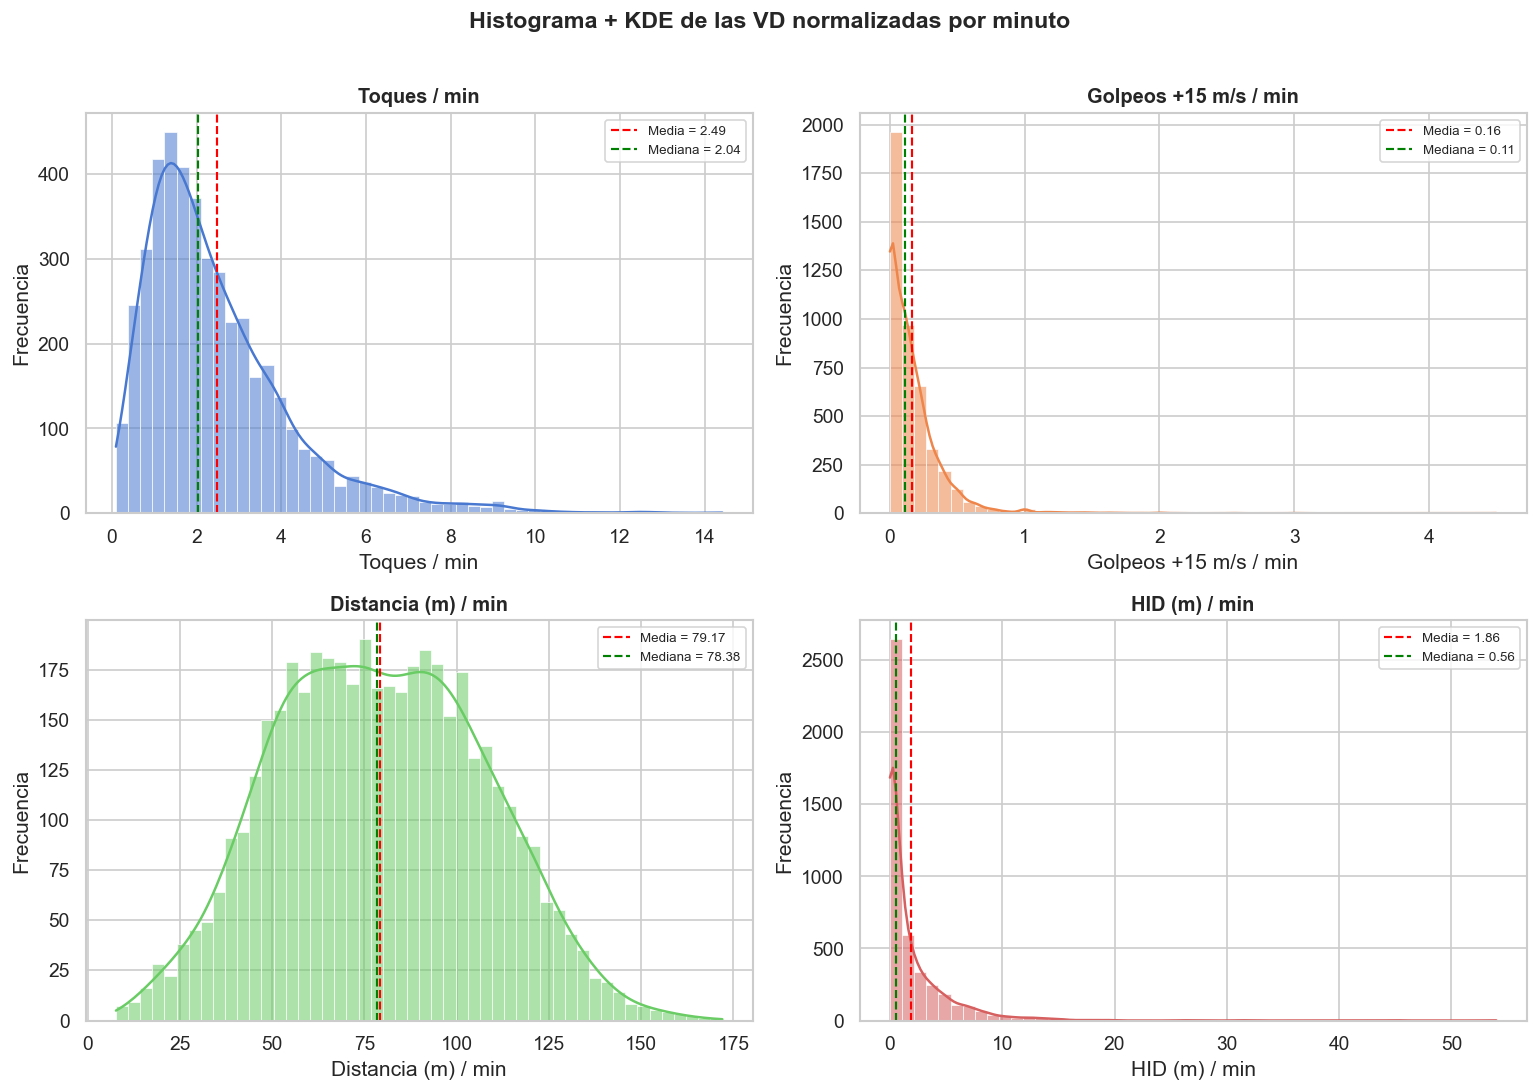

In [5]:
colores = sns.color_palette("muted", n_colors=4)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for i, (col, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[i]
    x = df[col].dropna()

    # Histograma + KDE
    sns.histplot(x, bins=50, kde=True, color=colores[i], alpha=0.55,
                 edgecolor="white", linewidth=0.4, ax=ax)

    # Líneas de referencia
    ax.axvline(x.mean(),   color="red",   ls="--", lw=1.3, label=f"Media = {x.mean():.2f}")
    ax.axvline(x.median(), color="green", ls="--", lw=1.3, label=f"Mediana = {x.median():.2f}")

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

fig.suptitle("Histograma + KDE de las VD normalizadas por minuto",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

---
## 6 · Resumen y decisiones

### Hallazgos principales del análisis univariante

1. **Ninguna VD sigue una distribución normal.** Los tres tests de normalidad (Shapiro-Wilk, D'Agostino-Pearson, Anderson-Darling) rechazan H₀ de forma contundente para las cuatro variables. La asimetría positiva y la leptocurtosis son rasgos comunes.

2. **Asimetría positiva generalizada.** Todas las VD/min presentan sesgo positivo (g₁ > 0), con media > mediana. Esto es esperable en métricas de rendimiento deportivo, donde la mayoría de las observaciones se concentra en valores bajos-medios con una cola derecha más extendida.

3. **Presencia relevante de ceros en dos VD.** `Golpeos +15 m/s / min` presenta un 29.51 % de ceros y `HID / min` un 30.09 %. Estos ceros representan fases de entrenamiento donde no se registraron golpeos de alta velocidad o carrera de alta intensidad. Las otras dos VD (`Toques / min` y `Distancia / min`) no presentan ceros.

4. **Sobredispersión.** El ratio V/M > 1 para la mayoría de variables confirma que la variabilidad es superior a la esperada bajo un modelo Poisson o Normal estándar.

### Distribución recomendada para cada VD (según resultados obtenidos)

La selección se basa en el AIC/BIC, la inspección visual de los Q-Q plots y el porcentaje de ceros:

| VD | Mejor familia (AIC) | % ceros | Recomendación GLMM |
|---|---|---|---|
| **Toques / min** | Gamma | 0.00 % | Gamma con enlace log |
| **Golpeos +15 m/s / min** | Inv. Gaussian (solo >0) | 29.51 % | **Tweedie** (1 < p < 2) o modelo hurdle |
| **Distancia (m) / min** | Weibull | 0.00 % | Gamma con enlace log |
| **HID (m) / min** | Lognormal (solo >0) | 30.09 % | **Tweedie** o modelo hurdle |

### Notas para fases posteriores

- **Toques / min** y **Distancia / min** no presentan ceros y se ajustan bien a distribuciones Gamma / Weibull → en el GLMM se usará una **familia Gamma con enlace logarítmico**.
- **Golpeos +15 m/s / min** y **HID / min** tienen ~30 % de ceros → la familia **Tweedie** (potencia entre 1 y 2) es la opción más parsimoniosa, ya que modela simultáneamente la masa puntual en cero y la distribución continua positiva. Como alternativa, un **modelo hurdle** (logístico para P(Y=0) + Gamma/Lognormal para Y > 0) ofrece mayor flexibilidad a costa de más parámetros.
- En el siguiente notebook de EDA se abordará el **análisis bivariante** para explorar relaciones entre las VD y las variables independientes (factores de diseño del entrenamiento).

### 3.2 Boxplot + Violin plot combinados

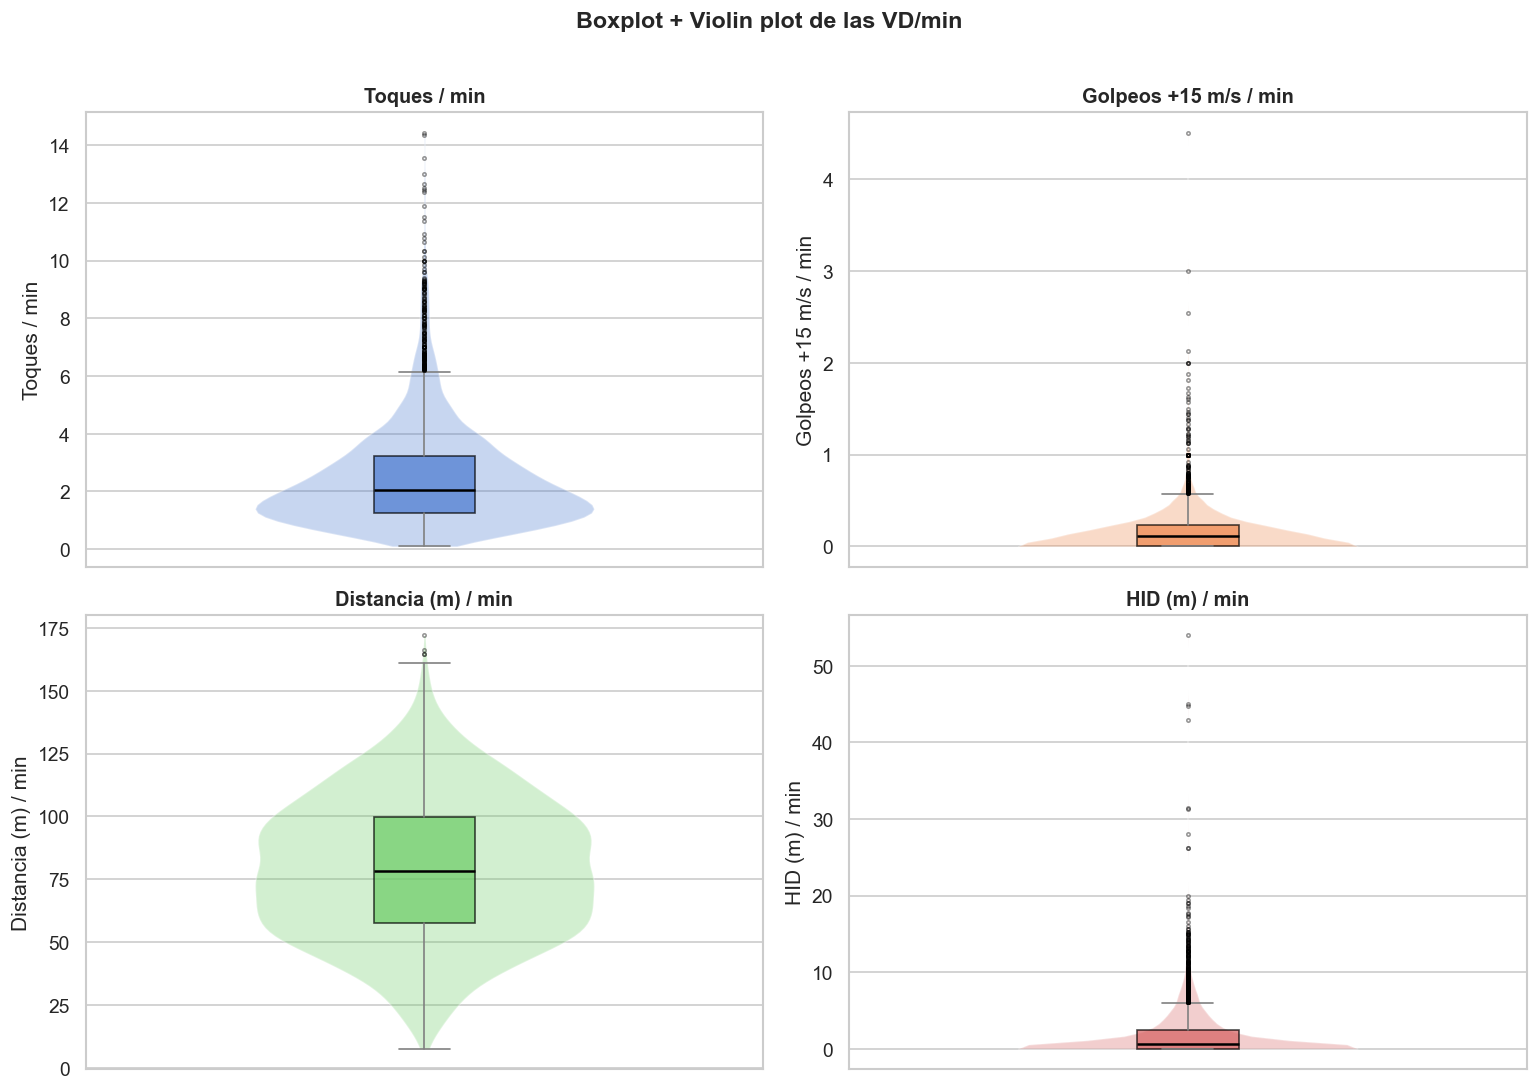

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for i, (col, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[i]
    x = df[col].dropna()

    # Violin plot de fondo
    parts = ax.violinplot(x, positions=[0], showmedians=False, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(colores[i])
        pc.set_alpha(0.30)

    # Boxplot superpuesto
    bp = ax.boxplot(x, positions=[0], widths=0.15, patch_artist=True,
                    boxprops=dict(facecolor=colores[i], alpha=0.7),
                    medianprops=dict(color="black", lw=1.5),
                    whiskerprops=dict(color="grey"),
                    capprops=dict(color="grey"),
                    flierprops=dict(marker="o", markersize=2, alpha=0.4))

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel(label)
    ax.set_xticks([])

fig.suptitle("Boxplot + Violin plot de las VD/min",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

### 3.3 Q-Q plots contra distribuciones teóricas (Normal, Lognormal, Gamma)

Cada fila corresponde a una VD y cada columna a una distribución de referencia.  
Si los puntos siguen la diagonal, la distribución teórica es un buen candidato.

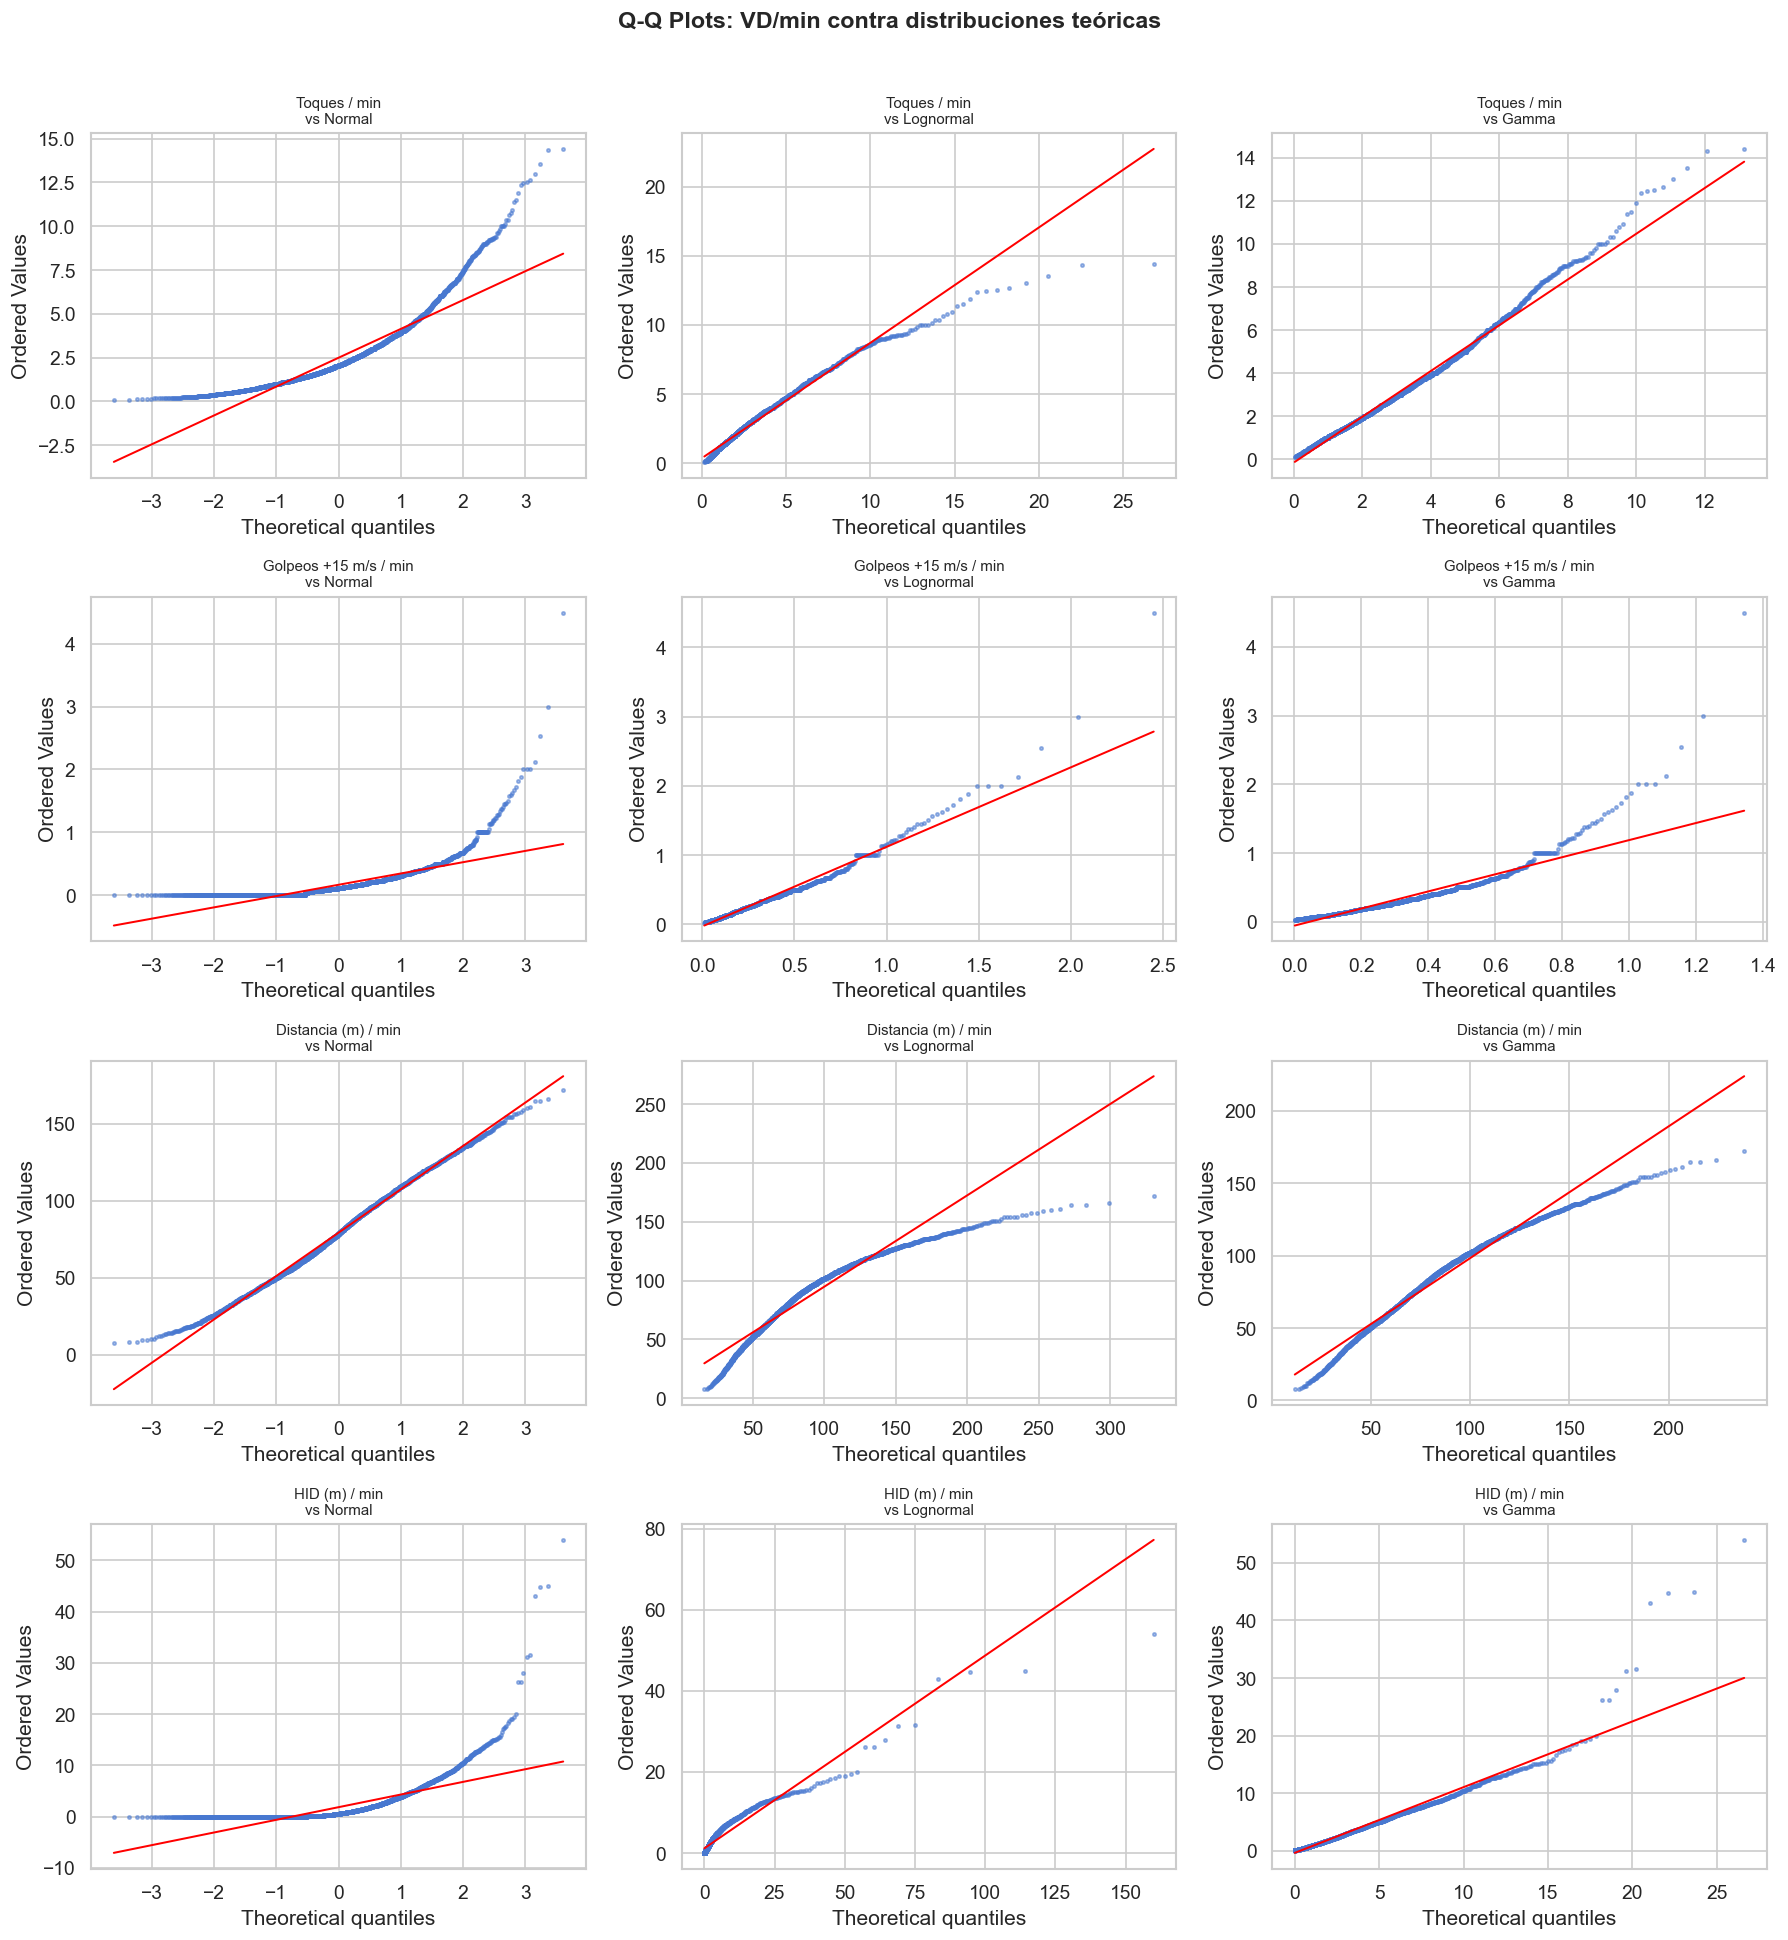

In [7]:
dist_refs = [
    ("norm",    "Normal"),
    ("lognorm", "Lognormal"),
    ("gamma",   "Gamma"),
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row, (col, label) in enumerate(zip(vd_cols, vd_labels)):
    x = df[col].dropna().values
    # Para lognormal y gamma solo usamos valores > 0
    x_pos = x[x > 0]

    for j, (dist_name, dist_label) in enumerate(dist_refs):
        ax = axes[row, j]
        datos = x if dist_name == "norm" else x_pos

        if dist_name == "lognorm":
            # scipy.probplot con lognorm necesita parámetros ajustados
            shape, loc, scale = stats.lognorm.fit(datos, floc=0)
            stats.probplot(datos, dist=stats.lognorm(shape, loc=loc, scale=scale), plot=ax)
        elif dist_name == "gamma":
            a, loc, scale = stats.gamma.fit(datos, floc=0)
            stats.probplot(datos, dist=stats.gamma(a, loc=loc, scale=scale), plot=ax)
        else:
            stats.probplot(datos, dist="norm", plot=ax)

        ax.set_title(f"{label}\nvs {dist_label}", fontsize=9)
        ax.get_lines()[0].set(markersize=2, alpha=0.5)
        ax.get_lines()[1].set(color="red", lw=1.2)

fig.suptitle("Q-Q Plots: VD/min contra distribuciones teóricas",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

---
## 4 · Tests de normalidad

Aplicamos tres tests complementarios. Los tres contrastan:

- **H₀:** Los datos provienen de una distribución normal.  
- **H₁:** Los datos **no** provienen de una distribución normal.

| Test | Sensibilidad |
|---|---|
| **Shapiro-Wilk** | Potente para muestras pequeñas-medianas |
| **D'Agostino-Pearson** | Basado en asimetría + curtosis |
| **Anderson-Darling** | Énfasis en las colas de la distribución |

In [8]:
filas_norm = []

for col, label in zip(vd_cols, vd_labels):
    x = df[col].dropna().values

    # Shapiro-Wilk (limitamos a 5000 observaciones como requiere scipy)
    stat_sw, p_sw = stats.shapiro(x[:5000])

    # D'Agostino-Pearson
    stat_da, p_da = stats.normaltest(x)

    # Anderson-Darling
    result_ad = stats.anderson(x, dist="norm")
    stat_ad = result_ad.statistic
    # Nivel de significación al 5 %
    cv_5 = result_ad.critical_values[2]  # índice 2 → 5 %
    decision_ad = "Rechaza H₀" if stat_ad > cv_5 else "No rechaza H₀"

    filas_norm.append({
        "Variable": label,
        "SW stat": stat_sw,
        "SW p-valor": p_sw,
        "DA stat": stat_da,
        "DA p-valor": p_da,
        "AD stat": stat_ad,
        "AD VC 5 %": cv_5,
        "AD decisión": decision_ad,
    })

df_norm = pd.DataFrame(filas_norm).set_index("Variable")

df_norm.style.format({
    "SW stat":    "{:.4f}",
    "SW p-valor": "{:.2e}",
    "DA stat":    "{:.2f}",
    "DA p-valor": "{:.2e}",
    "AD stat":    "{:.2f}",
    "AD VC 5 %":  "{:.3f}",
}).set_caption("Tabla 2 — Tests de normalidad (α = 0.05)")

,SW stat,SW p-valor,DA stat,DA p-valor,AD stat,AD VC 5 %,AD decisión
Variable,,,,,,,
Toques / min,0.8611,1.13e-52,1617.43,0.00e+00,140.77,0.752,Rechaza H₀
Golpeos +15 m/s / min,0.6613,2.49e-69,4570.16,0.00e+00,281.93,0.752,Rechaza H₀
Distancia (m) / min,0.9949,2.39e-11,85.47,2.75e-19,6.29,0.752,Rechaza H₀
HID (m) / min,0.5957,6.45e-73,4446.51,0.00e+00,478.63,0.752,Rechaza H₀


### Interpretación de los tests de normalidad

Los tres tests rechazan de forma contundente la hipótesis de normalidad para las cuatro VD/min (p-valores extremadamente pequeños). Esto era esperable dada:

1. La **asimetría positiva** observada en la Sección 2.  
2. La presencia de **ceros** en variables como `Golpeos +15 m/s / min` y `HID / min`.  
3. El **exceso de curtosis**, que indica colas más pesadas que la distribución normal.

**Conclusión:** No podemos asumir normalidad para ninguna VD. En la Sección 5 exploraremos distribuciones alternativas (Gamma, Lognormal, Weibull, Inverse Gaussian) y evaluaremos cuál se ajusta mejor a cada variable.

---
## 5 · Ajuste de distribuciones (MLE)

**Estrategia:**

- **Normal y Weibull** se ajustan sobre todos los datos (incluyendo ceros).  
- **Lognormal, Gamma e Inverse Gaussian** requieren soporte estrictamente positivo → se ajustan solo sobre valores `> 0`.  
- Calculamos AIC y BIC para comparar ajustes.  
- Si una VD tiene un porcentaje de ceros relevante (>5 %), señalamos la necesidad de un modelo Tweedie o hurdle.

In [17]:
def calcular_aic_bic(log_lik, k, n):
    """Calcula AIC y BIC a partir de la log-verosimilitud."""
    aic = 2 * k - 2 * log_lik
    bic = k * np.log(n) - 2 * log_lik
    return aic, bic


def ajustar_distribucion(datos, nombre_dist, dist_scipy, n_params, floc=None):
    """
    Ajusta una distribución por MLE y devuelve parámetros, AIC y BIC.
    Si el log-likelihood contiene -inf (e.g., Weibull evaluado en x=0),
    se descarta el ajuste.
    """
    try:
        if floc is not None:
            params = dist_scipy.fit(datos, floc=floc)
        else:
            params = dist_scipy.fit(datos)
        log_pdf = dist_scipy.logpdf(datos, *params)
        # Descartar si hay -inf (densidad 0 en algún punto)
        if not np.all(np.isfinite(log_pdf)):
            return {"params": params, "log_lik": np.nan, "AIC": np.nan, "BIC": np.nan}
        log_lik = np.sum(log_pdf)
        n = len(datos)
        aic, bic = calcular_aic_bic(log_lik, n_params, n)
        return {"params": params, "log_lik": log_lik, "AIC": aic, "BIC": bic}
    except Exception as e:
        return {"params": None, "log_lik": np.nan, "AIC": np.nan, "BIC": np.nan}

In [18]:
# ── Distribuciones candidatas ─────────────────────────────
# (nombre, objeto scipy, nº parámetros, requiere >0, kwargs fit)
distribuciones = [
    ("Normal",           stats.norm,     2, False, {}),
    ("Weibull",          stats.weibull_min, 3, False, {"floc": 0}),
    ("Lognormal",        stats.lognorm,  3, True,  {"floc": 0}),
    ("Gamma",            stats.gamma,    3, True,  {"floc": 0}),
    ("Inverse Gaussian", stats.invgauss, 3, True,  {"floc": 0}),
]

# Almacenamos todos los resultados
resultados = {}  # {vd_label: {dist_name: {params, AIC, BIC, ...}}}

filas_aic = []

for col, label in zip(vd_cols, vd_labels):
    x_all = df[col].dropna().values
    x_pos = x_all[x_all > 0]
    pct_ceros = (x_all == 0).sum() / len(x_all) * 100
    resultados[label] = {}

    for dist_name, dist_obj, k, solo_pos, fit_kw in distribuciones:
        datos = x_pos if solo_pos else x_all
        res = ajustar_distribucion(datos, dist_name, dist_obj, k, **fit_kw)
        resultados[label][dist_name] = res
        resultados[label][dist_name]["n_datos"] = len(datos)

        filas_aic.append({
            "Variable": label,
            "Distribución": dist_name,
            "n": len(datos),
            "% ceros": pct_ceros,
            "Log-Lik": res["log_lik"],
            "AIC": res["AIC"],
            "BIC": res["BIC"],
        })

df_aic = pd.DataFrame(filas_aic)

# Resaltar el mejor AIC por variable
def resaltar_minimo(s):
    es_min = s == s.min()
    return ["font-weight: bold; background-color: #d4edda" if v else "" for v in es_min]

df_aic_pivot = df_aic.pivot_table(
    index="Variable", columns="Distribución",
    values=["AIC", "BIC"], aggfunc="first"
)

# Tabla completa
df_aic.style.format({
    "n":       "{:.0f}",
    "% ceros": "{:.2f}",
    "Log-Lik": "{:.1f}",
    "AIC":     "{:.1f}",
    "BIC":     "{:.1f}",
}).set_caption("Tabla 3 — Comparación de ajustes (MLE): AIC y BIC por VD y distribución")

,Variable,Distribución,n,% ceros,Log-Lik,AIC,BIC
0,Toques / min,Normal,4446,0.00,-8861.7,17727.3,17740.1
1,Toques / min,Weibull,4446,0.00,-7941.3,15888.5,15907.7
2,Toques / min,Lognormal,4446,0.00,-7870.1,15746.2,15765.4
3,Toques / min,Gamma,4446,0.00,-7836.3,15678.5,15697.7
4,Toques / min,Inverse Gaussian,4446,0.00,-7995.5,15997.1,16016.3
5,Golpeos +15 m/s / min,Normal,4446,29.51,392.8,-781.7,-768.9
6,Golpeos +15 m/s / min,Weibull,4446,29.51,nan,nan,nan
7,Golpeos +15 m/s / min,Lognormal,3134,29.51,1956.2,-3906.5,-3888.3
8,Golpeos +15 m/s / min,Gamma,3134,29.51,1719.8,-3433.7,-3415.5
9,Golpeos +15 m/s / min,Inverse Gaussian,3134,29.51,1965.6,-3925.3,-3907.1


In [19]:
# ── Tabla resumen: mejor distribución por AIC para cada VD ──
mejor_por_vd = (
    df_aic.loc[df_aic.groupby("Variable")["AIC"].idxmin()]
    [["Variable", "Distribución", "% ceros", "AIC", "BIC"]]
    .set_index("Variable")
)

mejor_por_vd.style.format({
    "% ceros": "{:.2f}",
    "AIC":     "{:.1f}",
    "BIC":     "{:.1f}",
}).set_caption("Tabla 4 — Mejor distribución por AIC para cada VD")

,Distribución,% ceros,AIC,BIC
Variable,,,,
Distancia (m) / min,Weibull,0.00,42246.5,42265.7
Golpeos +15 m/s / min,Inverse Gaussian,29.51,-3925.3,-3907.1
HID (m) / min,Lognormal,30.09,12130.2,12148.3
Toques / min,Gamma,0.00,15678.5,15697.7


### 5.1 Overlay: histograma + PDF de la mejor distribución

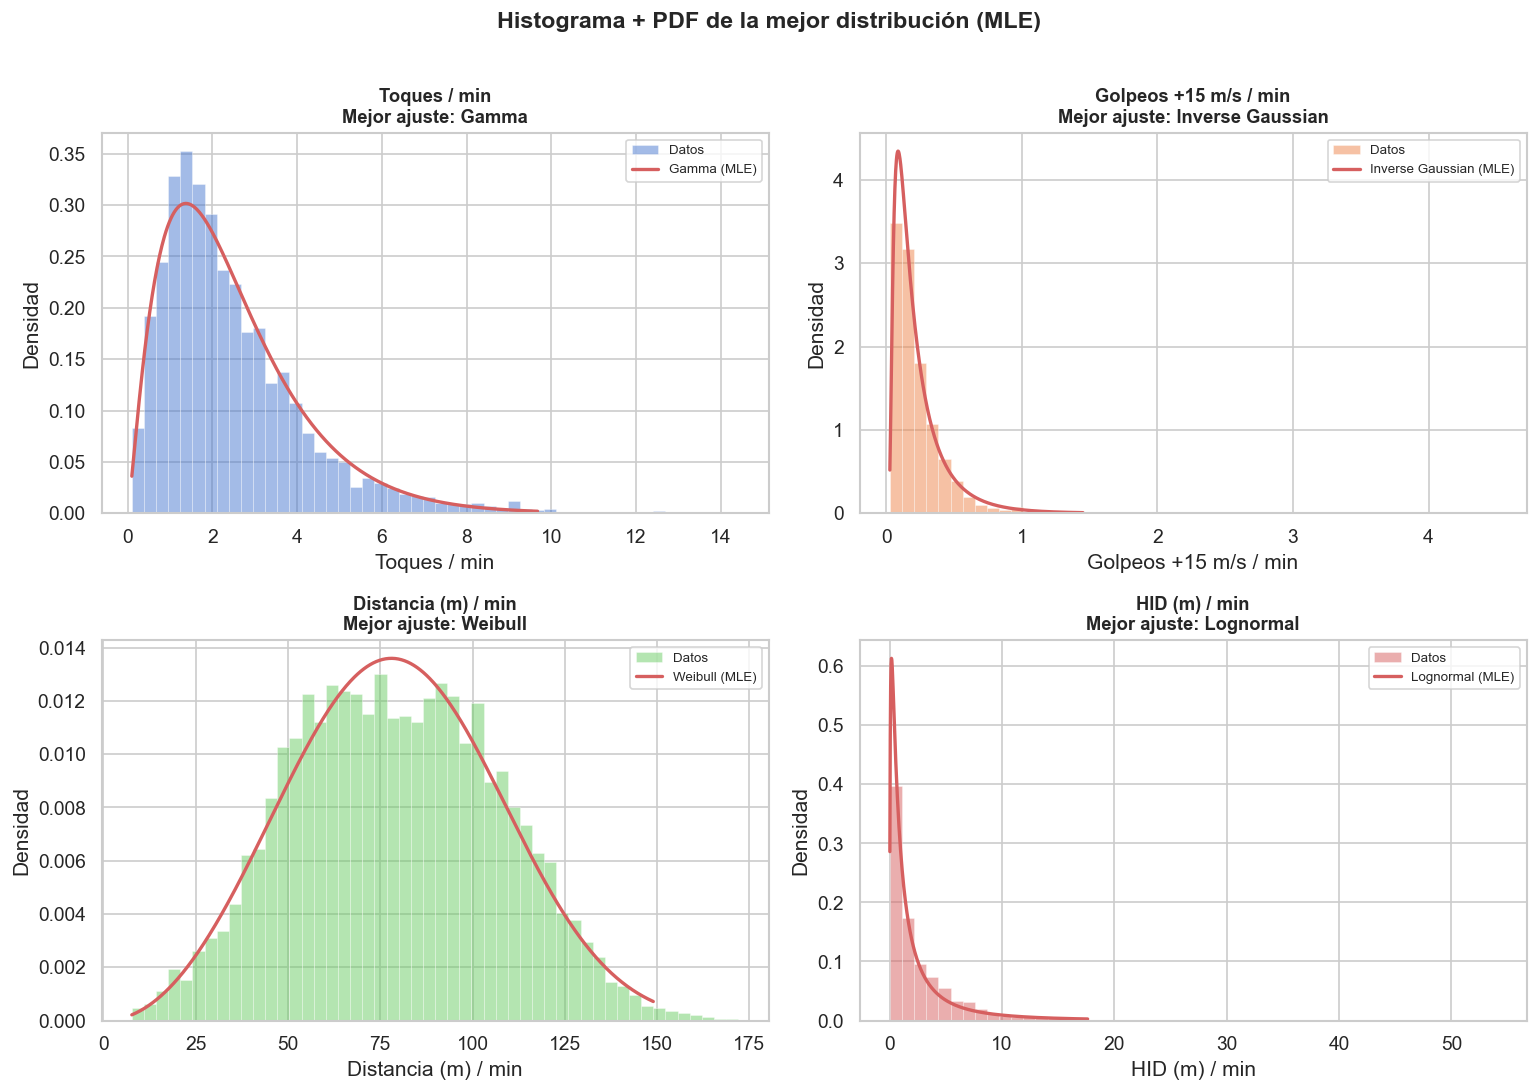

In [20]:
# Mapa de distribuciones scipy para referencia rápida
dist_map = {
    "Normal":           stats.norm,
    "Weibull":          stats.weibull_min,
    "Lognormal":        stats.lognorm,
    "Gamma":            stats.gamma,
    "Inverse Gaussian": stats.invgauss,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for i, (col, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[i]
    x_all = df[col].dropna().values
    x_pos = x_all[x_all > 0]

    # Mejor distribución según AIC
    mejor_nombre = mejor_por_vd.loc[label, "Distribución"]
    mejor_res    = resultados[label][mejor_nombre]
    dist_obj     = dist_map[mejor_nombre]
    params       = mejor_res["params"]

    # Elegir datos según si la distribución requiere > 0
    solo_pos = mejor_nombre in ("Lognormal", "Gamma", "Inverse Gaussian")
    datos = x_pos if solo_pos else x_all

    # Histograma normalizado (densidad)
    ax.hist(datos, bins=50, density=True, alpha=0.5, color=colores[i],
            edgecolor="white", linewidth=0.4, label="Datos")

    # PDF ajustada
    x_grid = np.linspace(datos.min(), np.percentile(datos, 99.5), 500)
    pdf_vals = dist_obj.pdf(x_grid, *params)
    ax.plot(x_grid, pdf_vals, "r-", lw=2, label=f"{mejor_nombre} (MLE)")

    ax.set_title(f"{label}\nMejor ajuste: {mejor_nombre}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

fig.suptitle("Histograma + PDF de la mejor distribución (MLE)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

### 5.2 Nota sobre el porcentaje de ceros y modelos recomendados

In [13]:
# ── Porcentaje de ceros por VD ────────────────────────────
print("Porcentaje de ceros por variable:")
print("=" * 45)
for col, label in zip(vd_cols, vd_labels):
    x = df[col].dropna().values
    pct = (x == 0).sum() / len(x) * 100
    marca = " ⚠️  (>5 %, considerar Tweedie/hurdle)" if pct > 5 else ""
    print(f"  {label:30s} → {pct:6.2f} %{marca}")

Porcentaje de ceros por variable:
  Toques / min                   →   0.00 %
  Golpeos +15 m/s / min          →  29.51 % ⚠️  (>5 %, considerar Tweedie/hurdle)
  Distancia (m) / min            →   0.00 %
  HID (m) / min                  →  30.09 % ⚠️  (>5 %, considerar Tweedie/hurdle)


**Implicaciones para el modelado (GLMM):**

- **VD sin ceros o con % de ceros ≤ 5 %:** Se puede usar directamente una familia Gamma o Lognormal con enlace log en el GLMM.  
- **VD con % de ceros > 5 %:** La familia **Tweedie** (potencia entre 1 y 2) es la opción más parsimoniosa, ya que modela simultáneamente la masa puntual en cero y la distribución continua positiva. Alternativamente, un **modelo hurdle** (logístico para P(Y=0) + Gamma/Lognormal para Y > 0) permite mayor flexibilidad a costa de más parámetros.

En la siguiente fase de modelado se evaluará cuál de estas estrategias se ajusta mejor a cada VD.

---
## 6 · Resumen y decisiones

### Hallazgos principales del análisis univariante

1. **Ninguna VD sigue una distribución normal.** Los tres tests de normalidad (Shapiro-Wilk, D'Agostino-Pearson, Anderson-Darling) rechazan H₀ de forma contundente para las cuatro variables. La asimetría positiva y la leptocurtosis son rasgos comunes.

2. **Asimetría positiva generalizada.** Todas las VD/min presentan sesgo positivo (g₁ > 0), con media > mediana. Esto es esperable en métricas de rendimiento deportivo, donde la mayoría de las observaciones se concentra en valores bajos-medios con una cola derecha más extendida.

3. **Presencia relevante de ceros en dos VD.** `Golpeos +15 m/s / min` presenta un 29.51 % de ceros y `HID / min` un 30.09 %. Estos ceros representan fases de entrenamiento donde no se registraron golpeos de alta velocidad o carrera de alta intensidad. Las otras dos VD (`Toques / min` y `Distancia / min`) no presentan ceros.

4. **Sobredispersión.** El ratio V/M > 1 para la mayoría de variables confirma que la variabilidad es superior a la esperada bajo un modelo Poisson o Normal estándar.

### Distribución recomendada para cada VD (según resultados obtenidos)

La selección se basa en el AIC/BIC, la inspección visual de los Q-Q plots y el porcentaje de ceros:

| VD | Mejor familia (AIC) | % ceros | Recomendación GLMM |
|---|---|---|---|
| **Toques / min** | Gamma | 0.00 % | Gamma con enlace log |
| **Golpeos +15 m/s / min** | Inv. Gaussian (solo >0) | 29.51 % | **Tweedie** (1 < p < 2) o modelo hurdle |
| **Distancia (m) / min** | Weibull | 0.00 % | Gamma con enlace log |
| **HID (m) / min** | Lognormal (solo >0) | 30.09 % | **Tweedie** o modelo hurdle |

### Notas para fases posteriores

- **Toques / min** y **Distancia / min** no presentan ceros y se ajustan bien a distribuciones Gamma / Weibull → en el GLMM se usará una **familia Gamma con enlace logarítmico**.
- **Golpeos +15 m/s / min** y **HID / min** tienen ~30 % de ceros → la familia **Tweedie** (potencia entre 1 y 2) es la opción más parsimoniosa, ya que modela simultáneamente la masa puntual en cero y la distribución continua positiva. Como alternativa, un **modelo hurdle** (logístico para P(Y=0) + Gamma/Lognormal para Y > 0) ofrece mayor flexibilidad a costa de más parámetros.
- En el siguiente notebook de EDA se abordará el **análisis bivariante** para explorar relaciones entre las VD y las variables independientes (factores de diseño del entrenamiento).